# Setup check: the workspace, proved

Week 0, Monday. This notebook runs in any codespace made from GitHub's Jupyter starter, and it asks
one thing: does the workspace do what the next twenty weeks will ask of it?

Run every cell from the top. The first prints five lines that should all start with PASS. The next
three each draw a chart, because a notebook that cannot draw is not ready either. The numbers are
this afternoon's own blocks and the programme's weeks, so there is nothing to interpret yet.

In [1]:
import os, sys, tempfile
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

folder = tempfile.mkdtemp()
path = os.path.join(folder, "check.csv")
pd.DataFrame({"block": ["welcome", "setup", "self-rating"], "minutes": [90, 60, 15]}).to_csv(path, index=False)
back = pd.read_csv(path)

checks = [
    ("Python is 3.10 or later", sys.version_info >= (3, 10)),
    ("pandas imports", bool(pd.__version__)),
    ("matplotlib imports", bool(matplotlib.__version__)),
    ("a file written and read back holds 3 rows", len(back) == 3),
    ("the three blocks add to 165 minutes", int(back["minutes"].sum()) == 165),
]
for name, ok in checks:
    print(("PASS  " if ok else "FAIL  ") + name)

PASS  Python is 3.10 or later
PASS  pandas imports
PASS  matplotlib imports
PASS  a file written and read back holds 3 rows
PASS  the three blocks add to 165 minutes


## Chart one: this afternoon, block by block

A bar chart of the three blocks after the institute's first half: the welcome, setup and the
self-rating.

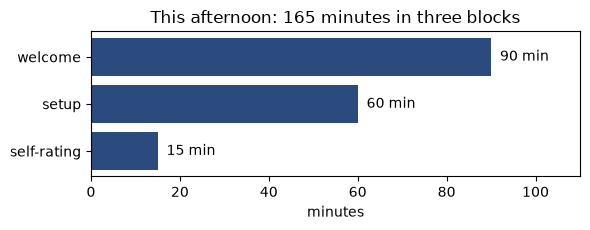

In [2]:
fig, ax = plt.subplots(figsize=(6, 2.4))
ax.barh(back["block"][::-1], back["minutes"][::-1], color="#2b4a7d")
for y, m in enumerate(back["minutes"][::-1]):
    ax.text(m + 2, y, f"{m} min", va="center")
ax.set_xlabel("minutes")
ax.set_xlim(0, 110)
ax.set_title("This afternoon: 165 minutes in three blocks")
plt.tight_layout()
plt.show()

## Chart two: the twenty-one weeks, by kind

The rhythm from the welcome: Week 0 first, then two teaching weeks and a build week, five times,
then the design-to-deploy week and the four capstone weeks.

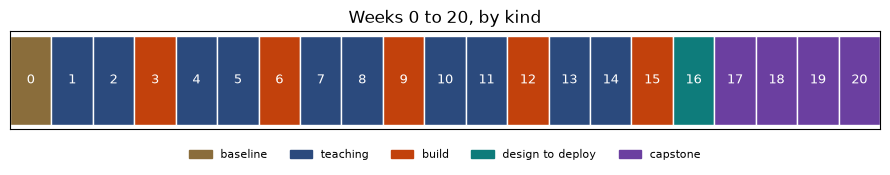

kind
teaching            10
build                5
capstone             4
baseline             1
design to deploy     1


In [3]:
kinds = {0: "baseline", 16: "design to deploy"}
for w in (3, 6, 9, 12, 15):
    kinds[w] = "build"
for w in (17, 18, 19, 20):
    kinds[w] = "capstone"
weeks = pd.DataFrame({"week": range(21)})
weeks["kind"] = [kinds.get(w, "teaching") for w in weeks["week"]]
colours = {"baseline": "#8a6d3b", "teaching": "#2b4a7d", "build": "#c2410c",
           "design to deploy": "#0e7c7b", "capstone": "#6b3fa0"}

fig, ax = plt.subplots(figsize=(9, 1.9))
for _, row in weeks.iterrows():
    ax.barh(0, 1, left=row["week"], color=colours[row["kind"]], edgecolor="white")
    ax.text(row["week"] + 0.5, 0, str(row["week"]), ha="center", va="center", color="white", fontsize=9)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 21)
ax.set_title("Weeks 0 to 20, by kind")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colours.values()]
ax.legend(handles, colours.keys(), ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
print(weeks["kind"].value_counts().to_string())

## Chart three: the afternoon, adding up

The same three blocks as a running total, which is the shape a timetable is checked in.

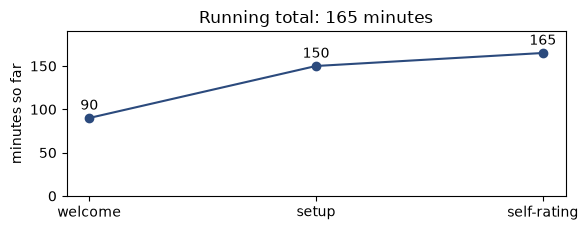

In [4]:
running = back["minutes"].cumsum()
fig, ax = plt.subplots(figsize=(6, 2.4))
ax.plot(back["block"], running, marker="o", color="#2b4a7d")
for x, y in zip(back["block"], running):
    ax.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 6), ha="center")
ax.set_ylabel("minutes so far")
ax.set_ylim(0, 190)
ax.set_title("Running total: 165 minutes")
plt.tight_layout()
plt.show()

## What this proves

Five PASS lines and three charts mean the codespace, Python, pandas, matplotlib and the notebook
editor all work, and that a file can be written and read back. Stop the codespace when you finish:
closing the tab does not stop it.